In [1]:
import gcinfo
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
gcinfo.list_resources(gcinfo.search_datasets(query='title:"Resettled Refugees"')["results"][0])


=== (ARCHIVED) Resettled Refugees – Monthly IRCC Updates ===
ID: 4a1b260a-7ac4-4985-80a0-603bfe4aec11
Org: Immigration, Refugees and Citizenship Canada | Immigration, Réfugiés et Citoyenneté Canada
Notes: Resettled refugees who arrived in Canada as part of the Government of Canada's Refugee and Humanitarian Resettlement Program. Datasets include resettled refugees who have received settlement services....
Citation: Immigration, Refugees and Citizenship Canada. (ARCHIVED) Resettled Refugees – Monthly IRCC Updates
  [XLSX    ] (ARCHIVED) Canada - Resettled Refugees by Country of Citizenship and Immigration Category
           https://www.ircc.canada.ca/opendata-donneesouvertes/data/EN_ODP-Resettled_Refugees-Admissions-CITZ.xlsx
  [XLSX    ] (ARCHIVED) Canada - Resettled Refugees by Country of Citizenship and Immigration Category
           https://www.ircc.canada.ca/opendata-donneesouvertes/data/FR_ODP-Resettled_Refugees-Admissions-CITZ.xlsx
  [CSV     ] (ARCHIVED) [rounded numbers - no

In [3]:
df = gcinfo.download_xlsx("https://www.ircc.canada.ca/opendata-donneesouvertes/data/EN_ODP-Resettled_Refugees-Admissions-CITZ.xlsx")
df

Using cached file: cache\EN_ODP-Resettled_Refugees-Admissions-CITZ.xlsx


,"Canada - Admissions of Resettled Refugees by Country of Citizenship and Immigration Category, January 2015 - March 2025",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,NaN,NaN,NaN,NaN,NaN
1,Country of Citizenship,Blended Sponsorship Refugee,Government-Assisted Refugee,Privately Sponsored Refugee,Total
2,Afghanistan,85,"31,945","30,255","62,280"
3,Albania,0,--,5,5
4,Algeria,0,15,10,25
...,...,...,...,...,...
142,Total,"9,085","144,290","181,320","334,695"
143,NaN,NaN,NaN,NaN,NaN
144,Notes:\n— Please note that all values between ...,NaN,NaN,NaN,NaN
145,NaN,NaN,NaN,NaN,NaN


In [4]:
country_of_citizenship = pd.Series(df.iloc[2:142,0].tolist())
country_of_citizenship

0              Afghanistan
1                  Albania
2                  Algeria
3                   Angola
4      Antigua and Barbuda
              ...         
135              Venezuela
136                Vietnam
137                  Yemen
138                 Zambia
139               Zimbabwe
Length: 140, dtype: object

In [5]:
country_of_citizenship_no_comma = country_of_citizenship.apply(lambda x: x.split(",")[0])
country_of_citizenship_no_comma

0              Afghanistan
1                  Albania
2                  Algeria
3                   Angola
4      Antigua and Barbuda
              ...         
135              Venezuela
136                Vietnam
137                  Yemen
138                 Zambia
139               Zimbabwe
Length: 140, dtype: object

In [6]:
blended_government_assisted_privately_sponsored_total_refugee = df.iloc[2:142,1:]
blended_government_assisted_privately_sponsored_total_refugee

,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4
2,85,"31,945","30,255","62,280"
3,0,--,5,5
4,0,15,10,25
5,5,10,--,15
6,0,--,0,--
...,...,...,...,...
137,20,590,25,630
138,5,190,95,290
139,10,535,535,"1,080"
140,0,5,--,5


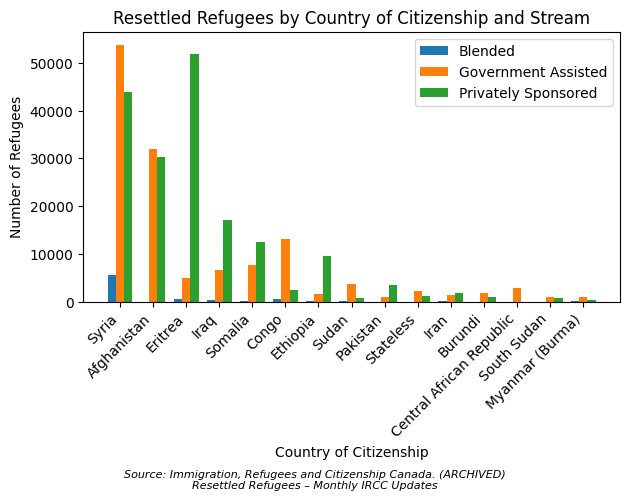

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Clean and align the data ---
# country_of_citizenship_no_comma is a Series
# blended_government_assisted_privately_sponsored_total_refugee is a DataFrame with 4 columns

df = blended_government_assisted_privately_sponsored_total_refugee.copy()
df.columns = ["Blended", "Government Assisted", "Privately Sponsored", "Total"]

# Align lengths and combine
countries = country_of_citizenship_no_comma.iloc[:len(df)].reset_index(drop=True)
df = df.reset_index(drop=True)
df.insert(0, "Country", countries)

# Drop non-country rows (Total, Notes, Source, NaNs)
df = df[df["Country"].notna()]
df = df[~df["Country"].astype(str).str.contains("Total|Notes|Source", case=False, na=False)]

# Clean numeric columns: replace "--", remove commas, convert to numbers
for col in ["Blended", "Government Assisted", "Privately Sponsored", "Total"]:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .replace("--", "0")
        .replace("nan", "0")
        .astype(float)
        .fillna(0)
        .astype(int)
    )

# Keep only top 15 countries by Total so the plot is readable
df = df.nlargest(15, "Total").sort_values("Total", ascending=False).reset_index(drop=True)

# --- Plot ---
countries = df["Country"].tolist()
blended = df["Blended"].tolist()
government_assisted = df["Government Assisted"].tolist()
privately_sponsored = df["Privately Sponsored"].tolist()

x = np.arange(len(countries))
width = 0.25

fig, ax = plt.subplots()

ax.bar(x - width, blended, width, label="Blended")
ax.bar(x, government_assisted, width, label="Government Assisted")
ax.bar(x + width, privately_sponsored, width, label="Privately Sponsored")

ax.set_title("Resettled Refugees by Country of Citizenship and Stream")
ax.set_xlabel("Country of Citizenship")
ax.set_ylabel("Number of Refugees")
ax.set_xticks(x)
ax.set_xticklabels(countries)
plt.xticks(rotation=45, ha="right")

ax.legend(
    title=None,
    loc="upper right",
    frameon=True
)

plt.figtext(
    0.5, -0.03,
    "Source: Immigration, Refugees and Citizenship Canada. (ARCHIVED)\nResettled Refugees – Monthly IRCC Updates",
    ha="center",
    fontsize=8,
    style="italic"
)

plt.subplots_adjust(bottom=0.3)
plt.tight_layout()
plt.show()